In [23]:
#-------Set up environment--------
library(dplyr)
library(Seurat)
library(httr)
library(readr)
library(harmony)
library(MAST)
library(unixtools)
library(ggplot2)
library(cowplot)
library(ggmin)
library(future)
library(repr)
library(pheatmap)
set_config(config(ssl_verifypeer = 0L))
ulimit::memory_limit(250000)
setwd("/data/lucy/MacroFibroAtlas/TotalMFTIntegration/")
set.tempdir("/data/lucy/tmp/")
options(warn = -1, verbose=FALSE)

soft   hard 
250000    Inf

## Integrate macrophage and fibroblast from synovium, lung, skin and heart. 
In addition, we will also include t-cells to act as extra 'anchors' between the tissues. 

In [15]:
#Read in subsetted macrophage, fibroblast and t-cells from each tissue 
skinMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Skin/skinMFT.rds")
Idents(skinMFT) <- "MFT"
skinMFT$sample <- paste0(skinMFT$paper,"_",skinMFT$sample)
DefaultAssay(skinMFT) <- "integrated"
skinMFT <- DietSeurat(skinMFT, assays = c("RNA", "integrated"))
skinMFT$tissue <- "Skin"

synoMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Synovium/synoMFT.rds")
Idents(synoMFT) <- "MFT"
DefaultAssay(synoMFT) <- "integrated"
synoMFT <- DietSeurat(synoMFT, assays = c("RNA", "integrated"))
synoMFT$tissue <- "Synovium"

lungMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Lung/lungMFT.rds")
Idents(lungMFT) <- "MFT"
DefaultAssay(lungMFT) <- "integrated"
lungMFT <- DietSeurat(lungMFT, assays = c("RNA", "integrated"))
lungMFT$tissue <- "Lung"

heartMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Heart/heartMFT.rds")
Idents(heartMFT) <- "MFT"
DefaultAssay(heartMFT) <- "integrated"
heartMFT <- DietSeurat(heartMFT, assays = c("RNA", "integrated"))
heartMFT$tissue <- "Heart"

## How many cells of each type in each tissue atlas?


In [16]:
table(skinMFT$MFT)


Myeloid Stromal T Cells 
   8450   23544   10883 

In [17]:
table(synoMFT$MFT)


Myeloid Stromal T Cells 
  50698   31685   19399 

In [18]:
table(lungMFT$MFT)


Myeloid Stromal T Cells 
  65589    4916   17259 

In [19]:
table(heartMFT$MFT)


Myeloid Stromal T Cells 
  22838   59305   15166 

## Visualize the data pre-integration.

In [20]:
#Merge the data from various tissue to visualize pre-integration
mergedMFTatlas <- merge(x=lungMFT, y=c(skinMFT,synoMFT,heartMFT), add.cell.ids=c("Lung","Skin","Synovium","Heart"))
DefaultAssay(mergedMFTatlas) <- "RNA"

#Need to remove integrated assay or harmony gets upset
mergedMFTatlas@assays$integrated <- NULL
VariableFeatures(mergedMFTatlas) <- c(VariableFeatures(lungMFT), VariableFeatures(skinMFT), 
                                      VariableFeatures(synoMFT), VariableFeatures(heartMFT))
mergedMFTatlas <- ScaleData(mergedMFTatlas, features = VariableFeatures(mergedMFTatlas))
mergedMFTatlas <- RunPCA(mergedMFTatlas, npcs = 50, verbose = FALSE)
#Visualize umap pre-integration 
mergedMFTatlas <- RunUMAP(mergedMFTatlas, reduction = "pca", dims = 1:30)
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap", group.by="tissue") + theme_powerpoint()

Centering and scaling data matrix

11:06:04 UMAP embedding parameters a = 0.9922 b = 1.112

11:06:05 Read 329732 rows and found 30 numeric columns

11:06:05 Using Annoy for neighbor search, n_neighbors = 30

11:06:05 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*

|

11:07:47 Writing NN index file to temp file /data/lucy/tmp//filec9c93c3737a9

11:07:47 Searching Annoy index using 1 thread, search_k = 3000

11:10:11 Annoy recall = 100%

11:10:15 Commencing smooth kNN distance calibration using 1 thread

11:10:42 Initializing from normalized Laplacian + noise

11:12:31 Commencing optimization for 200 epochs, with 14699332 positive edges

11:21:26 Optimization finished



ERROR: Error in theme_powerpoint(): could not find function "theme_powerpoint"


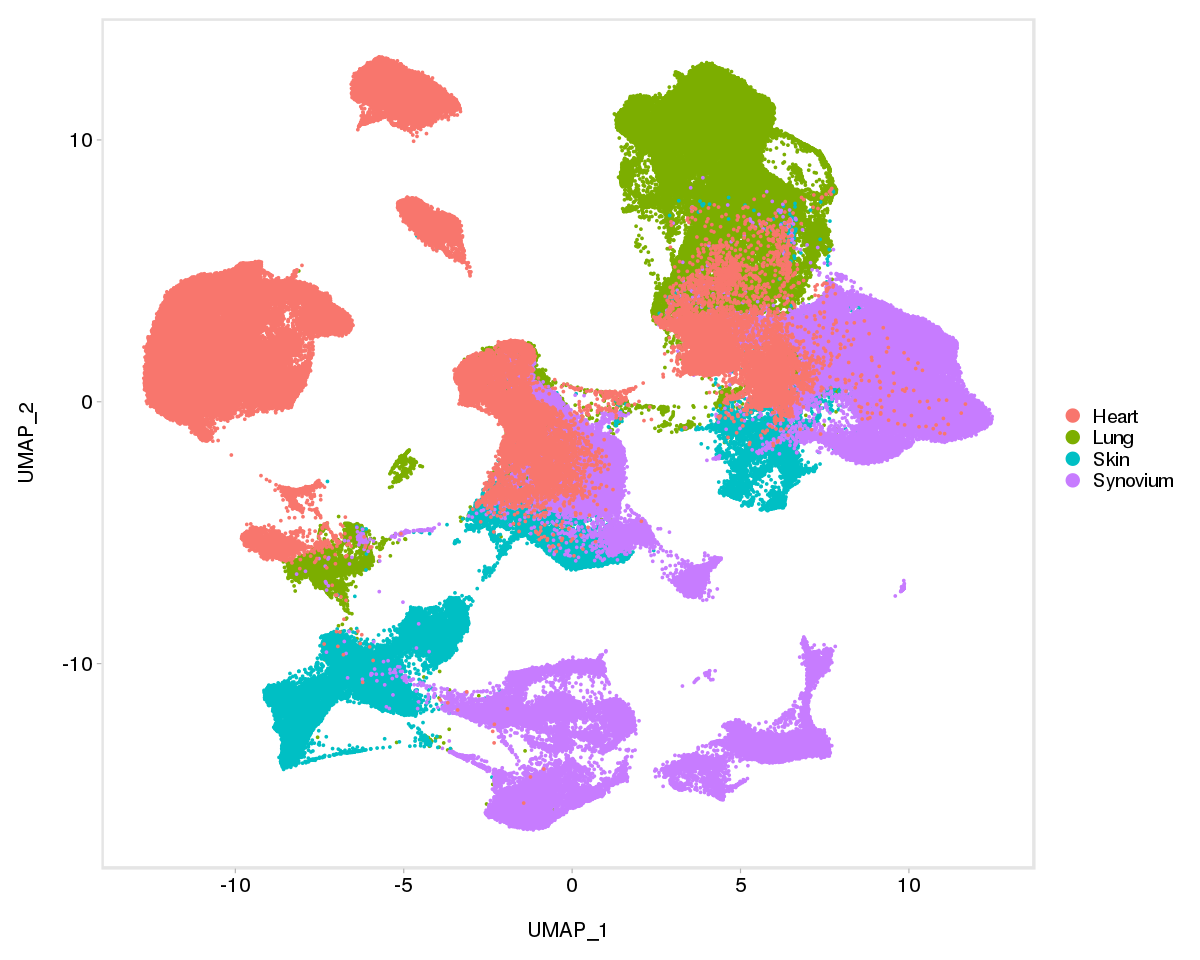

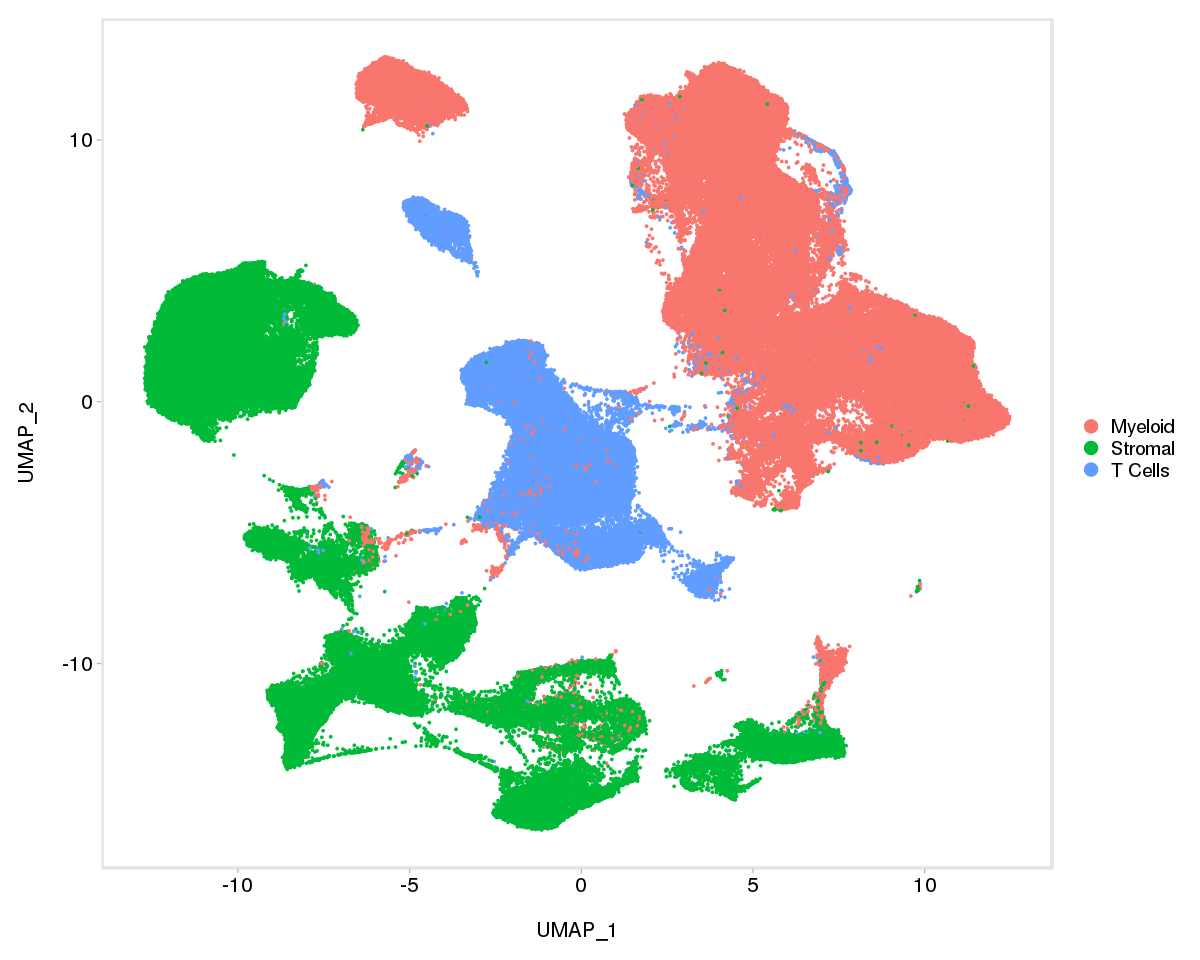

In [24]:
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap", group.by="tissue") + theme_powerpoint()
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap", group.by="MFT") + theme_powerpoint()

In [25]:
saveRDS(mergedMFTatlas, "mergedMFTatlas.rds")

In [26]:
table(mergedMFTatlas$sample)


                    C1                     C2           CER_SynBio23 
                   117                     34                   2868 
          CER_SynBio26           CER_SynBio28           CER_SynBio49 
                  4818                   3365                    629 
          CER_SynBio50                     D1                     D2 
                  2338                     70                    222 
                    D4                     D5             H0015_apex 
                    70                     18                    846 
          H0015_LA_new               H0015_LV               H0015_RA 
                   616                    807                    591 
              H0015_RV           H0015_septum             H0020_apex 
                   252                    859                    290 
          H0020_LA_new               H0020_LV               H0020_RA 
                   750                    938                    747 
              H0020

In [28]:
mergedMFTatlas

An object of class Seurat 
42203 features across 329732 samples within 1 assay 
Active assay: RNA (42203 features, 5083 variable features)
 2 dimensional reductions calculated: pca, umap

In [27]:
#This step was completed by downloading object and running on my local R studio 
#as todata1 does not have SeuratDisk installed
#mergedMFTatlas <- DietSeurat(mergedMFTatlas, scale.data=FALSE)
#mergedMFTatlas <- ScaleData(mergedMFTatlas, features=rownames(mergedMFTatlas))
#mergedMFTatlas <- FindVariableFeatures(mergedMFTatlas, nfeatures=6000)
#saveRDS(mergedMFTatlas, "mergedMFTatlas.rds")
#SaveH5Seurat(mergedMFTatlas, overwrite = TRUE)
#Convert(source="mergedMFTatlas.h5Seurat", to = "anndata", dest = "mergedMFTatlas.h5ad")